In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
#load datset
df = pd.read_csv('/content/warfarin.csv')

In [4]:
#remove whitspaces from column names
df.columns = df.columns.str.strip()

In [5]:
#renaming the column
df.rename(columns={'Therapeutic Dow': 'Therapeutic Dose'}, inplace=True)

In [6]:
#dataset dimensions
print("Shape:", df.shape)

# data types
print(df.dtypes)

# fiest 5 rows
print(df.head())

Shape: (5700, 11)
Gender                  object
Race                    object
Age                     object
Height                 float64
Weight                 float64
Diabetes               float64
Simvastatin            float64
Amiodarone             float64
INR on ReportedDose    float64
genotype                object
Therapeutic Dose       float64
dtype: object
   Gender   Race      Age  Height  Weight  Diabetes  Simvastatin  Amiodarone  \
0    male  White  60 - 69  193.04   115.7       NaN          0.0         0.0   
1  female  White  50 - 59  176.53   144.2       NaN          0.0         0.0   
2  female  White  40 - 49  162.56    77.1       NaN          0.0         0.0   
3    male  White  60 - 69  182.24    90.7       NaN          0.0         0.0   
4    male  White  50 - 59  167.64    72.6       NaN          0.0         0.0   

   INR on ReportedDose genotype  Therapeutic Dose  
0                 2.60      A/G              49.0  
1                 2.15      A/A           

In [7]:
# age range string to a  single numeric value (midpoint)
def age_to_mid(age_str):
    try:
        parts = age_str.split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    except:
        return np.nan

df['Age_numeric'] = df['Age'].apply(age_to_mid)

In [8]:
print("\nMissing values before filling:\n", df.isnull().sum())


Missing values before filling:
 Gender                    4
Race                    506
Age                      42
Height                 1146
Weight                  287
Diabetes               2417
Simvastatin            1839
Amiodarone             1518
INR on ReportedDose     732
genotype               1654
Therapeutic Dose        172
Age_numeric              91
dtype: int64


In [9]:
# filling missing values:

# with mode (most frequent values)
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Race'] = df['Race'].fillna(df['Race'].mode()[0])

# with median
df['Age_numeric'] = df['Age_numeric'].fillna(df['Age_numeric'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

# as unknown
df['genotype'] = df['genotype'].fillna("Unknown")

# consider missing vals as no Simvastatin/Amiodaeone
df['Simvastatin'] = df['Simvastatin'].fillna(0)
df['Amiodarone'] = df['Amiodarone'].fillna(0)

# remove the rows for missing vals
df = df.dropna(subset=['Therapeutic Dose'])


In [10]:
print("Shape:", df.shape)

Shape: (5528, 12)


In [11]:
# summary statistics for numeric columns
df.describe()

,Height,Weight,Diabetes,Simvastatin,Amiodarone,INR on ReportedDose,Therapeutic Dose,Age_numeric
count,4447.000000,5528.000000,3126.000000,5528.000000,5528.000000,4968.000000,5528.000000,5528.000000
mean,168.062035,77.706368,0.190339,0.098408,0.047576,2.364436,30.977873,63.754703
std,10.839539,21.420254,0.392631,0.297893,0.212887,0.464645,16.801040,14.185117
min,124.970000,30.000000,0.000000,0.000000,0.000000,0.800000,2.100000,24.500000
25%,160.020000,63.000000,0.000000,0.000000,0.000000,2.100000,19.530000,54.500000
50%,167.890000,75.000000,0.000000,0.000000,0.000000,2.400000,28.000000,64.500000
75%,176.020000,88.900000,0.000000,0.000000,0.000000,2.610000,38.500000,74.500000
max,202.000000,237.700000,1.000000,1.000000,1.000000,6.100000,315.000000,84.500000


In [22]:
# counts for each gender
df['Gender'].value_counts()

,count
Gender,
male,3224
female,2304


In [23]:
# counts for each race
df['Race'].value_counts()

,count
Race,
White,2641
Japanese,828
Caucasian,662
Korean,263
Han Chinese,250
Black,244
Black or African American,231
Chinese,142
Malay,82


In [24]:
# counts for each genotype
df['genotype'].value_counts()

,count
genotype,
Unknown,1633
A/A,1443
A/G,1353
G/G,1099


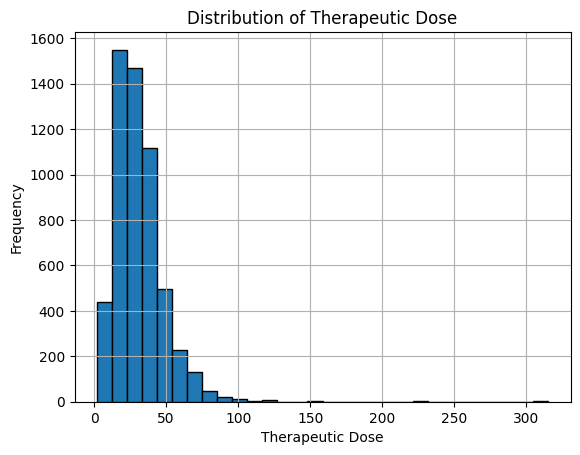

In [14]:
# visualization of theraputic does distribution
df['Therapeutic Dose'].hist(bins=30, edgecolor='black')
plt.xlabel('Therapeutic Dose')
plt.ylabel('Frequency')
plt.title('Distribution of Therapeutic Dose')
plt.show()


In [15]:
# pearson correlation for numeric columns
corr = df.corr(numeric_only=True)
corr['Therapeutic Dose'].sort_values(ascending=False)

,Therapeutic Dose
Therapeutic Dose,1.000000
Weight,0.380350
Height,0.313894
INR on ReportedDose,0.188573
Simvastatin,0.068831
Diabetes,0.036591
Amiodarone,-0.047708
Age_numeric,-0.277224


In [16]:
# one-hot encoding for categorical features
numeric_features = ['Age_numeric', 'Weight', 'Height', 'INR on ReportedDose',
                    'Simvastatin', 'Diabetes', 'Amiodarone']
categorical_features = ['Gender', 'Race', 'genotype']
X_numeric = df[numeric_features]
X_categorical = pd.get_dummies(df[categorical_features], drop_first=False)

In [17]:
# input feature matric and the target variable
X = pd.concat([X_numeric, X_categorical], axis=1)
y = df['Therapeutic Dose']

In [18]:
# splitting the data (training 80%, testing 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [19]:
# standardize numeric features (mean 0, standard deviation 1)
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [ ]:
# initialize Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# set up GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

#Fit the model on training data and search for best hyperparameters
grid_search.fit(X_train, y_train)

In [21]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Optimized Random Forest RMSE: {rmse:.2f}")
print(f"Optimized Random Forest R²: {r2:.2f}")


Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Optimized Random Forest RMSE: 12.44
Optimized Random Forest R²: 0.37
